# ImageNet Feature Selection Hyperparameter Search


## Импорты


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from modules.imagenet_feature_selection_benchmark import (
    collect_imagenet_val_image_paths,
    default_imagenet_feature_selection_tasks,
)
from modules.imagenet_feature_selection_hparam_search import (
    default_cheap_ig_search_space,
    render_imagenet_feature_selection_search_report,
    run_staged_imagenet_feature_selection_search,
    split_search_holdout_tasks,
)


## Параметры


In [2]:
IMAGENET_VAL_ROOT = Path("imagenet_val")
LAYER_NAME = "model.6"
SEARCH_FRACTION = 0.75
SPLIT_SEED = 0
TRAIN_PER_CLASS = 30
EVAL_PER_CLASS = 20
RANDOM_SEED = 0
CHANNEL_AGGREGATION = "positive_mean"
SELECTION_RULE = "max_over_classes"
SEARCH_SPACE = default_cheap_ig_search_space()
CACHE_ROOT = Path("output/imagenet_feature_selection_cache")
OUTPUT_DIR = Path("output/imagenet_feature_selection_hparam_search")
REFRESH_CORE = False
REFRESH_METHODS = False
TOP_N = 0
FD_EPS = 1e-3
CLEAR_EVERY = 8


## Датасет


In [3]:
IMAGE_PATHS = collect_imagenet_val_image_paths(IMAGENET_VAL_ROOT)
len(IMAGE_PATHS), IMAGE_PATHS[:3]


(50000,
 ['imagenet_val/n01440764/ILSVRC2012_val_00000293.JPEG',
  'imagenet_val/n01440764/ILSVRC2012_val_00002138.JPEG',
  'imagenet_val/n01440764/ILSVRC2012_val_00003014.JPEG'])

## Tasks


In [4]:
CLASS_TASKS = default_imagenet_feature_selection_tasks(IMAGENET_VAL_ROOT, random_seed=RANDOM_SEED)
CLASS_TASKS


[{'name': 'dogs_related',
  'wnids': ['n02085620', 'n02085782', 'n02085936', 'n02086079', 'n02086240']},
 {'name': 'cats_related',
  'wnids': ['n02123045', 'n02123159', 'n02123394', 'n02123597', 'n02124075']},
 {'name': 'random_a',
  'wnids': ['n04372370', 'n04275548', 'n03706229', 'n03109150', 'n02114548']},
 {'name': 'random_b',
  'wnids': ['n01682714', 'n01560419', 'n02231487', 'n02092339', 'n01773797']}]

## Search / Holdout Split


In [5]:
TASK_SPLIT = split_search_holdout_tasks(CLASS_TASKS, search_fraction=SEARCH_FRACTION, seed=SPLIT_SEED)
{
    "search": [task["name"] for task in TASK_SPLIT["search_tasks"]],
    "holdout": [task["name"] for task in TASK_SPLIT["holdout_tasks"]],
    "shuffled": TASK_SPLIT["shuffled_task_names"],
}


{'search': ['random_a', 'dogs_related', 'cats_related'],
 'holdout': ['random_b'],
 'shuffled': ['random_a', 'dogs_related', 'cats_related', 'random_b']}

## Search Space


In [6]:
segment_step_counts = pd.DataFrame(
    {
        f"seg={segment_end:g}": {
            n_steps: int((((pd.Series([i / (n_steps - 1) for i in range(n_steps)])) >= -1e-12) & ((pd.Series([i / (n_steps - 1) for i in range(n_steps)])) <= segment_end + 1e-12)).sum())
            for n_steps in SEARCH_SPACE["n_steps_values"]
        }
        for segment_end in SEARCH_SPACE["segment_end_values"]
    }
)
segment_step_counts.index.name = "n_steps"
SEARCH_SPACE, segment_step_counts


({'selection_mode': 'positive',
  'selection_top_k_values': [4000, 6000, 8000, 10000, 16000, 32000],
  'segment_start': 0.0,
  'segment_end_values': [0.1, 0.12, 0.15, 0.2],
  'fill_modes': ['zero', 'naa_scaled'],
  'fill_rho_values': [0.6, 0.8, 1.0, 1.2],
  'n_steps_values': [24, 48, 96, 192],
  'stage_a_n_steps': 48,
  'stage_b_n_steps': 48,
  'baseline_n_steps': 128,
  'stage_a_task_count': 2,
  'stage_a_limit': 6,
  'stage_b_limit': 8,
  'stage_a_hybrid_rho': 0.8,
  'k_values': [4, 8, 16, 32, 64]},
          seg=0.1  seg=0.12  seg=0.15  seg=0.2
 n_steps                                      
 24             3         3         4        5
 48             5         6         8       10
 96            10        12        15       20
 192           20        23        29       39)

## Запуск Search


In [ ]:
SEARCH_RESULT = run_staged_imagenet_feature_selection_search(
    image_paths=IMAGE_PATHS,
    imagenet_root=IMAGENET_VAL_ROOT,
    class_tasks=CLASS_TASKS,
    layer_name=LAYER_NAME,
    search_space=SEARCH_SPACE,
    search_fraction=SEARCH_FRACTION,
    seed=SPLIT_SEED,
    train_per_class=TRAIN_PER_CLASS,
    eval_per_class=EVAL_PER_CLASS,
    channel_aggregation=CHANNEL_AGGREGATION,
    selection_rule=SELECTION_RULE,
    cache_root=CACHE_ROOT,
    top_n=TOP_N,
    fd_eps=FD_EPS,
    clear_every=CLEAR_EVERY,
    refresh_core=REFRESH_CORE,
    refresh_methods=REFRESH_METHODS,
)

## Рендер Отчётов


In [8]:
ARTIFACTS = render_imagenet_feature_selection_search_report(SEARCH_RESULT, output_dir=OUTPUT_DIR)
ARTIFACTS


{'output_dir': 'output/imagenet_feature_selection_hparam_search',
 'figure_dir': 'output/imagenet_feature_selection_hparam_search/figures',
 'figures': {'stage_a_heatmap': 'output/imagenet_feature_selection_hparam_search/figures/stage_a_heatmap_1776710845186389000.png',
  'stage_b_rho_heatmap': 'output/imagenet_feature_selection_hparam_search/figures/stage_b_rho_heatmap_1776710845186389000.png',
  'nsteps_tradeoff': 'output/imagenet_feature_selection_hparam_search/figures/nsteps_tradeoff_1776710845186389000.png',
  'search_pareto_scatter': 'output/imagenet_feature_selection_hparam_search/figures/search_pareto_scatter_1776710845186389000.png',
  'search_parameter_effects': 'output/imagenet_feature_selection_hparam_search/figures/search_parameter_effects_1776710845186389000.png',
  'holdout_curves': 'output/imagenet_feature_selection_hparam_search/figures/holdout_curves_1776710845186389000.png',
  'holdout_summary': 'output/imagenet_feature_selection_hparam_search/figures/holdout_summary

## Search Report


In [9]:
display(Markdown(Path(ARTIFACTS["search_report_path"]).read_text(encoding="utf-8")))


# ImageNet Feature-Selection Hyperparameter Search

Staged Cheap-IG search on the ImageNet Sec. 5.2-style feature-selection benchmark.

## Configuration

- layer_name=`model.6`
- search_tasks=`['random_a', 'dogs_related', 'cats_related']`
- holdout_tasks=`['random_b']`
- k_values=`[4, 8, 16, 32, 64]`
- search_candidates_csv=`output/imagenet_feature_selection_hparam_search/search_candidates.csv`

## Stage A

| Method | Score | Std | Macro-F1 | Best acc | Best k | Runtime (s) | Status |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | --- |
| Cheap-IG+[0,0.2]/k16000/zero | 0.6420 | 0.1520 | 0.6328 | 0.7700 | 64 | 1.4537 | selected |
| Cheap-IG+[0,0.2]/k16000/naa_scaled/rho0.8 | 0.6420 | 0.1520 | 0.6328 | 0.7700 | 64 | 1.4565 | pruned |
| Cheap-IG+[0,0.2]/k8000/zero | 0.6410 | 0.1510 | 0.6333 | 0.7650 | 64 | 1.4534 | selected |
| Cheap-IG+[0,0.2]/k10000/zero | 0.6410 | 0.1510 | 0.6333 | 0.7650 | 64 | 1.4542 | pruned |
| Cheap-IG+[0,0.2]/k10000/naa_scaled/rho0.8 | 0.6410 | 0.1510 | 0.6333 | 0.7650 | 64 | 1.4566 | pruned |
| Cheap-IG+[0,0.2]/k8000/naa_scaled/rho0.8 | 0.6410 | 0.1510 | 0.6333 | 0.7650 | 64 | 1.4574 | pruned |
| Cheap-IG+[0,0.2]/k6000/zero | 0.6400 | 0.1500 | 0.6324 | 0.7650 | 64 | 1.4527 | selected |
| Cheap-IG+[0,0.2]/k6000/naa_scaled/rho0.8 | 0.6400 | 0.1500 | 0.6324 | 0.7650 | 64 | 1.4567 | pruned |
| Cheap-IG+[0,0.2]/k4000/zero | 0.6370 | 0.1570 | 0.6291 | 0.7500 | 64 | 1.4530 | pruned |
| Cheap-IG+[0,0.2]/k4000/naa_scaled/rho0.8 | 0.6370 | 0.1570 | 0.6291 | 0.7500 | 64 | 1.4565 | pruned |
| Cheap-IG+[0,0.2]/k32000/zero | 0.6350 | 0.1590 | 0.6261 | 0.7450 | 32 | 1.4548 | pruned |
| Cheap-IG+[0,0.2]/k32000/naa_scaled/rho0.8 | 0.6350 | 0.1590 | 0.6261 | 0.7450 | 32 | 1.4568 | pruned |
| Cheap-IG+[0,0.12]/k16000/zero | 0.6340 | 0.1620 | 0.6267 | 0.7650 | 64 | 1.3675 | selected |
| Cheap-IG+[0,0.12]/k16000/naa_scaled/rho0.8 | 0.6340 | 0.1620 | 0.6267 | 0.7650 | 64 | 1.3711 | pruned |
| Cheap-IG+[0,0.15]/k32000/zero | 0.6320 | 0.1620 | 0.6239 | 0.7700 | 64 | 1.4130 | pruned |
| Cheap-IG+[0,0.15]/k32000/naa_scaled/rho0.8 | 0.6320 | 0.1620 | 0.6239 | 0.7700 | 64 | 1.4132 | pruned |
| Cheap-IG+[0,0.1]/k4000/zero | 0.6310 | 0.1570 | 0.6218 | 0.7600 | 64 | 1.3447 | selected |
| Cheap-IG+[0,0.1]/k4000/naa_scaled/rho0.8 | 0.6310 | 0.1570 | 0.6218 | 0.7600 | 64 | 1.3474 | pruned |
| Cheap-IG+[0,0.1]/k32000/zero | 0.6300 | 0.1660 | 0.6251 | 0.7500 | 64 | 1.3474 | pruned |
| Cheap-IG+[0,0.1]/k32000/naa_scaled/rho0.8 | 0.6300 | 0.1660 | 0.6251 | 0.7500 | 64 | 1.3490 | pruned |
| Cheap-IG+[0,0.1]/k16000/zero | 0.6290 | 0.1670 | 0.6220 | 0.7600 | 64 | 1.3467 | pruned |
| Cheap-IG+[0,0.1]/k16000/naa_scaled/rho0.8 | 0.6290 | 0.1670 | 0.6220 | 0.7600 | 64 | 1.3490 | pruned |
| Cheap-IG+[0,0.12]/k8000/zero | 0.6290 | 0.1570 | 0.6204 | 0.7600 | 64 | 1.3666 | pruned |
| Cheap-IG+[0,0.12]/k10000/zero | 0.6290 | 0.1610 | 0.6213 | 0.7650 | 64 | 1.3667 | pruned |
| Cheap-IG+[0,0.12]/k8000/naa_scaled/rho0.8 | 0.6290 | 0.1570 | 0.6204 | 0.7600 | 64 | 1.3700 | pruned |
| Cheap-IG+[0,0.12]/k10000/naa_scaled/rho0.8 | 0.6290 | 0.1610 | 0.6213 | 0.7650 | 64 | 1.3701 | pruned |
| Cheap-IG+[0,0.12]/k32000/zero | 0.6280 | 0.1720 | 0.6206 | 0.7550 | 64 | 1.3695 | pruned |
| Cheap-IG+[0,0.12]/k32000/naa_scaled/rho0.8 | 0.6280 | 0.1720 | 0.6206 | 0.7550 | 64 | 1.3703 | pruned |
| Cheap-IG+[0,0.1]/k10000/zero | 0.6280 | 0.1660 | 0.6210 | 0.7450 | 64 | 1.3453 | pruned |
| Cheap-IG+[0,0.1]/k8000/zero | 0.6280 | 0.1660 | 0.6211 | 0.7500 | 64 | 1.3454 | pruned |
| Cheap-IG+[0,0.1]/k10000/naa_scaled/rho0.8 | 0.6280 | 0.1660 | 0.6210 | 0.7450 | 64 | 1.3485 | pruned |
| Cheap-IG+[0,0.1]/k8000/naa_scaled/rho0.8 | 0.6280 | 0.1660 | 0.6211 | 0.7500 | 64 | 1.3487 | pruned |
| Cheap-IG+[0,0.1]/k6000/zero | 0.6270 | 0.1590 | 0.6199 | 0.7450 | 64 | 1.3447 | selected |
| Cheap-IG+[0,0.1]/k6000/naa_scaled/rho0.8 | 0.6270 | 0.1590 | 0.6199 | 0.7450 | 64 | 1.3484 | pruned |
| Cheap-IG+[0,0.15]/k16000/zero | 0.6260 | 0.1620 | 0.6175 | 0.7600 | 64 | 1.4110 | pruned |
| Cheap-IG+[0,0.15]/k16000/naa_scaled/rho0.8 | 0.6260 | 0.1620 | 0.6175 | 0.7600 | 64 | 1.4139 | pruned |
| Cheap-IG+[0,0.12]/k6000/zero | 0.6240 | 0.1520 | 0.6149 | 0.7600 | 64 | 1.3666 | pruned |
| Cheap-IG+[0,0.12]/k6000/naa_scaled/rho0.8 | 0.6240 | 0.1520 | 0.6149 | 0.7600 | 64 | 1.3695 | pruned |
| Cheap-IG+[0,0.12]/k4000/zero | 0.6220 | 0.1540 | 0.6132 | 0.7600 | 64 | 1.3659 | pruned |
| Cheap-IG+[0,0.12]/k4000/naa_scaled/rho0.8 | 0.6220 | 0.1540 | 0.6132 | 0.7600 | 64 | 1.3697 | pruned |
| Cheap-IG+[0,0.15]/k4000/zero | 0.6220 | 0.1580 | 0.6132 | 0.7600 | 64 | 1.4088 | pruned |
| Cheap-IG+[0,0.15]/k10000/zero | 0.6220 | 0.1560 | 0.6130 | 0.7700 | 64 | 1.4097 | pruned |
| Cheap-IG+[0,0.15]/k4000/naa_scaled/rho0.8 | 0.6220 | 0.1580 | 0.6132 | 0.7600 | 64 | 1.4123 | pruned |
| Cheap-IG+[0,0.15]/k10000/naa_scaled/rho0.8 | 0.6220 | 0.1560 | 0.6130 | 0.7700 | 64 | 1.4134 | pruned |
| Cheap-IG+[0,0.15]/k6000/zero | 0.6200 | 0.1580 | 0.6125 | 0.7650 | 64 | 1.4089 | pruned |
| Cheap-IG+[0,0.15]/k6000/naa_scaled/rho0.8 | 0.6200 | 0.1580 | 0.6125 | 0.7650 | 64 | 1.4128 | pruned |
| Cheap-IG+[0,0.15]/k8000/zero | 0.6190 | 0.1590 | 0.6098 | 0.7650 | 64 | 1.4094 | pruned |
| Cheap-IG+[0,0.15]/k8000/naa_scaled/rho0.8 | 0.6190 | 0.1590 | 0.6098 | 0.7650 | 64 | 1.4128 | pruned |

## Stage B

| Method | Score | Std | Macro-F1 | Best acc | Best k | Runtime (s) | Status |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | --- |
| Cheap-IG+[0,0.2]/k16000/zero | 0.6420 | 0.1520 | 0.6328 | 0.7700 | 64 | 1.4537 | selected |
| Cheap-IG+[0,0.2]/k8000/zero | 0.6410 | 0.1510 | 0.6333 | 0.7650 | 64 | 1.4534 | selected |
| Cheap-IG+[0,0.2]/k6000/zero | 0.6400 | 0.1500 | 0.6324 | 0.7650 | 64 | 1.4527 | selected |
| Cheap-IG+[0,0.12]/k16000/zero | 0.6340 | 0.1620 | 0.6267 | 0.7650 | 64 | 1.3675 | selected |
| Cheap-IG+[0,0.1]/k4000/zero | 0.6310 | 0.1570 | 0.6218 | 0.7600 | 64 | 1.3447 | selected |
| Cheap-IG+[0,0.1]/k6000/zero | 0.6270 | 0.1590 | 0.6199 | 0.7450 | 64 | 1.3447 | selected |

## Stage C Finalists

| Label | Method | Score | Best acc | Runtime (s) |
| --- | --- | ---: | ---: | ---: |
| best_quality | Cheap-IG+[0,0.2]/k16000/zero | 0.5987 | 0.6967 | 0.7618 |
| fastest_pareto | Cheap-IG+[0,0.1]/k6000/zero | 0.5867 | 0.6933 | 0.7177 |
| best_balanced | Cheap-IG+[0,0.1]/k4000/zero | 0.5873 | 0.7000 | 0.7183 |

![](output/imagenet_feature_selection_hparam_search/figures/stage_a_heatmap_1776710845186389000.png)

![](output/imagenet_feature_selection_hparam_search/figures/stage_b_rho_heatmap_1776710845186389000.png)

![](output/imagenet_feature_selection_hparam_search/figures/nsteps_tradeoff_1776710845186389000.png)

![](output/imagenet_feature_selection_hparam_search/figures/search_pareto_scatter_1776710845186389000.png)

![](output/imagenet_feature_selection_hparam_search/figures/search_parameter_effects_1776710845186389000.png)


## Holdout Report


In [10]:
display(Markdown(Path(ARTIFACTS["holdout_report_path"]).read_text(encoding="utf-8")))


# ImageNet Feature-Selection Holdout Evaluation

- holdout_tasks=`['random_b']`
- k_values=`[4, 8, 16, 32, 64]`

## Finalists

| Label | Method | Score | Best acc | Runtime (s) |
| --- | --- | ---: | ---: | ---: |
| best_quality | Cheap-IG+[0,0.2]/k16000/zero | 0.5987 | 0.6967 | 0.7618 |
| fastest_pareto | Cheap-IG+[0,0.1]/k6000/zero | 0.5867 | 0.6933 | 0.7177 |
| best_balanced | Cheap-IG+[0,0.1]/k4000/zero | 0.5873 | 0.7000 | 0.7183 |

## Holdout Summary

| Method | Label | Mean accuracy over k | Std | Best acc | Best k | Macro-F1 AUC | Runtime (s) | Delta vs IG | Delta vs NAA |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| IG |  | 0.7080 | 0.0000 | 0.8500 | 64 | 0.7063 | 6.4091 | 0.0000 | 0.0720 |
| Cheap-IG+[0,0.1]/k4000/zero | best_balanced | 0.6680 | 0.0000 | 0.8500 | 64 | 0.6665 | 0.7084 | -0.0400 | 0.0320 |
| Cheap-IG+[0,0.1]/k6000/zero | fastest_pareto | 0.6640 | 0.0000 | 0.8500 | 64 | 0.6607 | 0.7080 | -0.0440 | 0.0280 |
| Cheap-IG+[0,0.2]/k16000/zero | best_quality | 0.6600 | 0.0000 | 0.8600 | 64 | 0.6544 | 0.7529 | -0.0480 | 0.0240 |
| NAA |  | 0.6360 | 0.0000 | 0.7600 | 64 | 0.6325 | 3.5956 | -0.0720 | 0.0000 |

## Pairwise Win Rate

| Left \\ Right | IG | NAA | Cheap-IG+[0,0.2]/k16000/zero | Cheap-IG+[0,0.1]/k6000/zero | Cheap-IG+[0,0.1]/k4000/zero |
| --- | ---: | ---: | ---: | ---: | ---: |
| IG | n/a | 1.000 | 0.600 | 0.600 | 0.600 |
| NAA | 0.000 | n/a | 0.400 | 0.400 | 0.400 |
| Cheap-IG+[0,0.2]/k16000/zero | 0.200 | 0.600 | n/a | 0.400 | 0.400 |
| Cheap-IG+[0,0.1]/k6000/zero | 0.000 | 0.600 | 0.400 | n/a | 0.000 |
| Cheap-IG+[0,0.1]/k4000/zero | 0.200 | 0.600 | 0.600 | 0.200 | n/a |

![](output/imagenet_feature_selection_hparam_search/figures/holdout_curves_1776710845186389000.png)

![](output/imagenet_feature_selection_hparam_search/figures/holdout_summary_1776710845186389000.png)


## Краткие Таблицы


In [11]:
stage_c_df = pd.DataFrame(SEARCH_RESULT["stages"]["C"]["candidate_records"])
stage_c_df = stage_c_df.sort_values(["accuracy_auc_mean", "runtime_mean"], ascending=[False, True])
stage_c_df[[
    "method_name",
    "accuracy_auc_mean",
    "best_accuracy_mean",
    "macro_f1_auc_mean",
    "runtime_mean",
    "n_steps",
    "segment_step_count",
    "stage_status",
    "final_label",
]].head(20)


,method_name,accuracy_auc_mean,best_accuracy_mean,macro_f1_auc_mean,runtime_mean,n_steps,segment_step_count,stage_status,final_label
5,"Cheap-IG+[0,0.2]/k16000/zero",0.598667,0.696667,0.590391,0.761770,24,5,finalist,best_quality
11,"Cheap-IG+[0,0.2]/k16000/zero",0.595333,0.703333,0.584897,1.415292,48,10,pruned,None
9,"Cheap-IG+[0,0.2]/k6000/zero",0.592667,0.706667,0.584256,1.414145,48,10,pruned,None
21,"Cheap-IG+[0,0.2]/k6000/zero",0.592000,0.706667,0.583291,4.414819,192,39,pruned,None
10,"Cheap-IG+[0,0.2]/k8000/zero",0.590667,0.693333,0.582012,1.414524,48,10,pruned,None
15,"Cheap-IG+[0,0.2]/k6000/zero",0.590667,0.710000,0.582080,2.310962,96,20,pruned,None
16,"Cheap-IG+[0,0.2]/k8000/zero",0.590667,0.703333,0.581739,2.312198,96,20,pruned,None
23,"Cheap-IG+[0,0.2]/k16000/zero",0.590667,0.700000,0.581800,4.417590,192,39,pruned,None
17,"Cheap-IG+[0,0.2]/k16000/zero",0.590000,0.693333,0.581424,2.313814,96,20,pruned,None
22,"Cheap-IG+[0,0.2]/k8000/zero",0.588667,0.693333,0.580434,4.414182,192,39,pruned,None


In [12]:
finalists_df = pd.DataFrame(SEARCH_RESULT["finalists"])
finalists_df


,label,method_name,config,config_key,config_step_key,n_steps,segment_step_count,accuracy_auc_mean,best_accuracy_mean,runtime_mean,fill_mode,fill_rho,segment_end,selection_top_k
0,best_quality,"Cheap-IG+[0,0.2]/k16000/zero","{'selection_mode': 'positive', 'selection_top_...","{""fill_mode"":""zero"",""fill_rho"":null,""segment_e...","{""config"":{""fill_mode"":""zero"",""fill_rho"":null,...",24,5,0.598667,0.696667,0.761770,zero,None,0.2,16000
1,fastest_pareto,"Cheap-IG+[0,0.1]/k6000/zero","{'selection_mode': 'positive', 'selection_top_...","{""fill_mode"":""zero"",""fill_rho"":null,""segment_e...","{""config"":{""fill_mode"":""zero"",""fill_rho"":null,...",24,3,0.586667,0.693333,0.717703,zero,None,0.1,6000
2,best_balanced,"Cheap-IG+[0,0.1]/k4000/zero","{'selection_mode': 'positive', 'selection_top_...","{""fill_mode"":""zero"",""fill_rho"":null,""segment_e...","{""config"":{""fill_mode"":""zero"",""fill_rho"":null,...",24,3,0.587333,0.700000,0.718279,zero,None,0.1,4000


In [13]:
holdout_df = pd.DataFrame(SEARCH_RESULT["stages"]["holdout"]["method_records"])
holdout_df[[
    "method_name",
    "label",
    "best_k_global",
    "best_accuracy_global",
    "delta_vs_ig",
    "delta_vs_naa",
]].sort_values(["best_accuracy_global", "method_name"], ascending=[False, True])


,method_name,label,best_k_global,best_accuracy_global,delta_vs_ig,delta_vs_naa
2,"Cheap-IG+[0,0.2]/k16000/zero",best_quality,64,0.86,-0.048,0.024
4,"Cheap-IG+[0,0.1]/k4000/zero",best_balanced,64,0.85,-0.040,0.032
3,"Cheap-IG+[0,0.1]/k6000/zero",fastest_pareto,64,0.85,-0.044,0.028
0,IG,None,64,0.85,0.000,0.072
1,NAA,None,64,0.76,-0.072,0.000


## Figure Gallery


### stage_a_heatmap

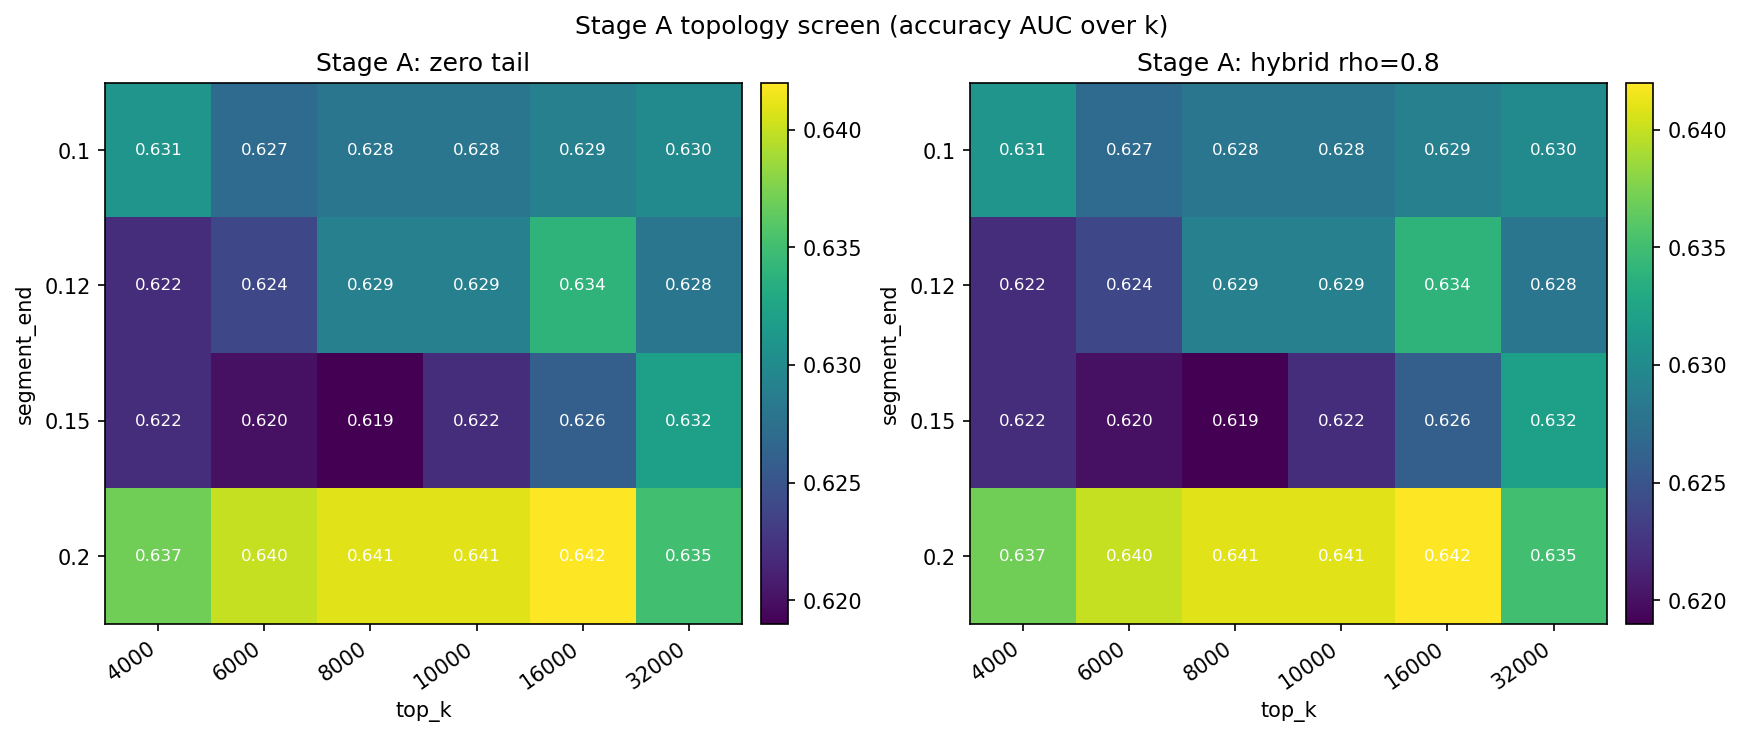

### stage_b_rho_heatmap

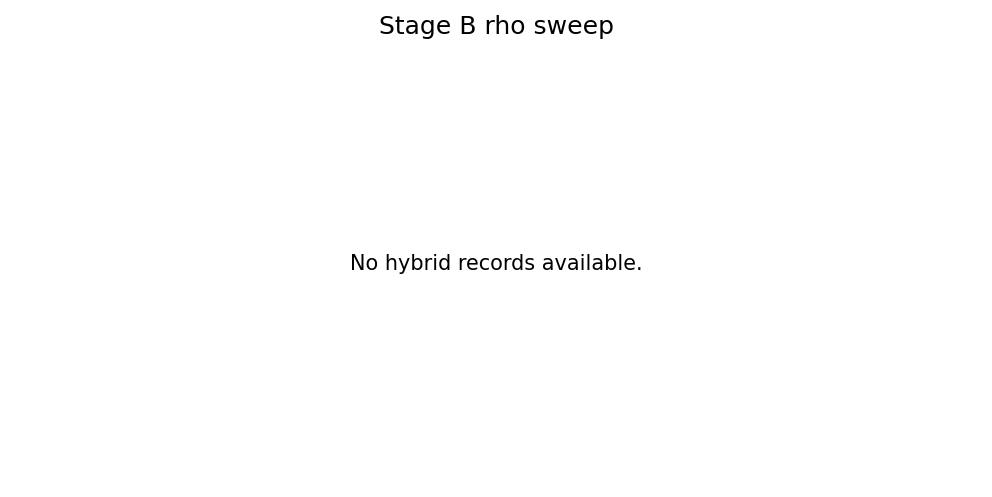

### nsteps_tradeoff

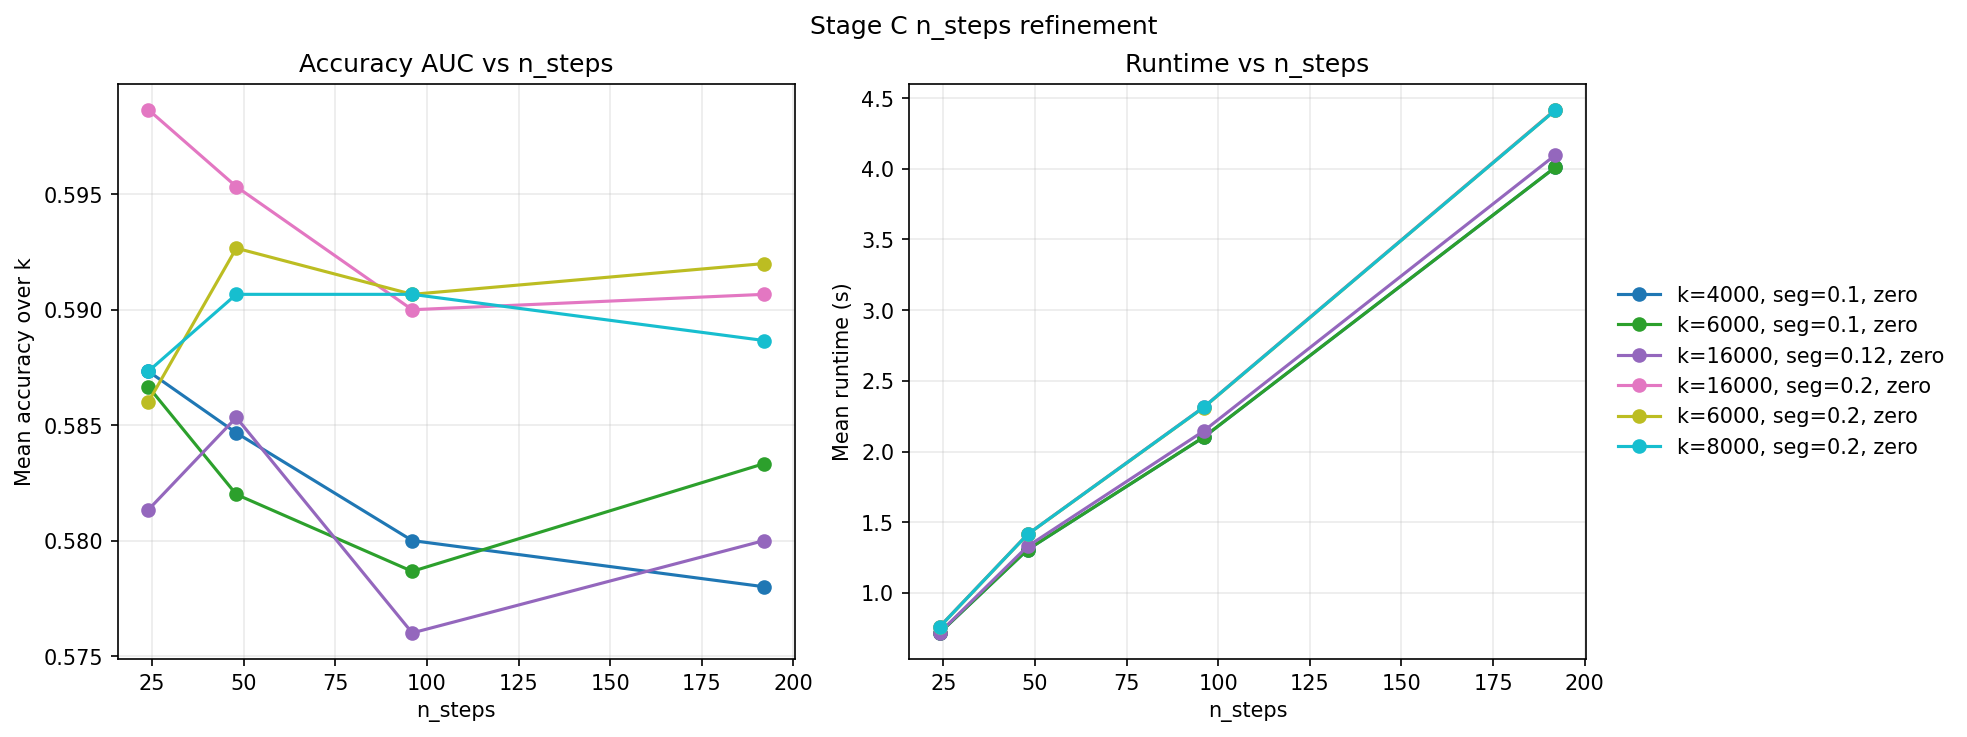

### search_pareto_scatter

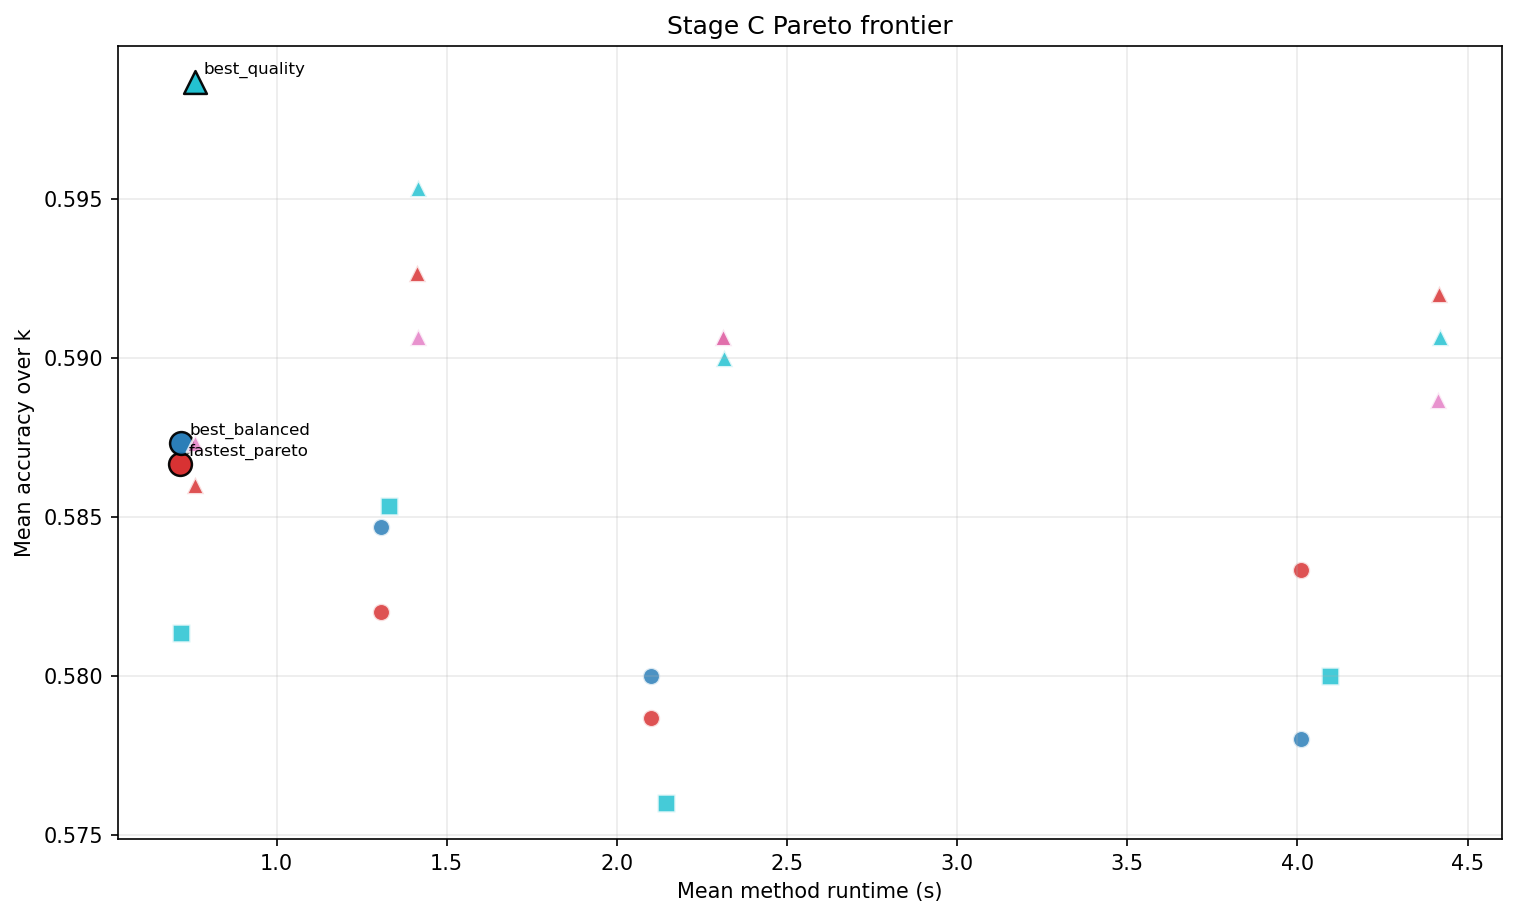

### search_parameter_effects

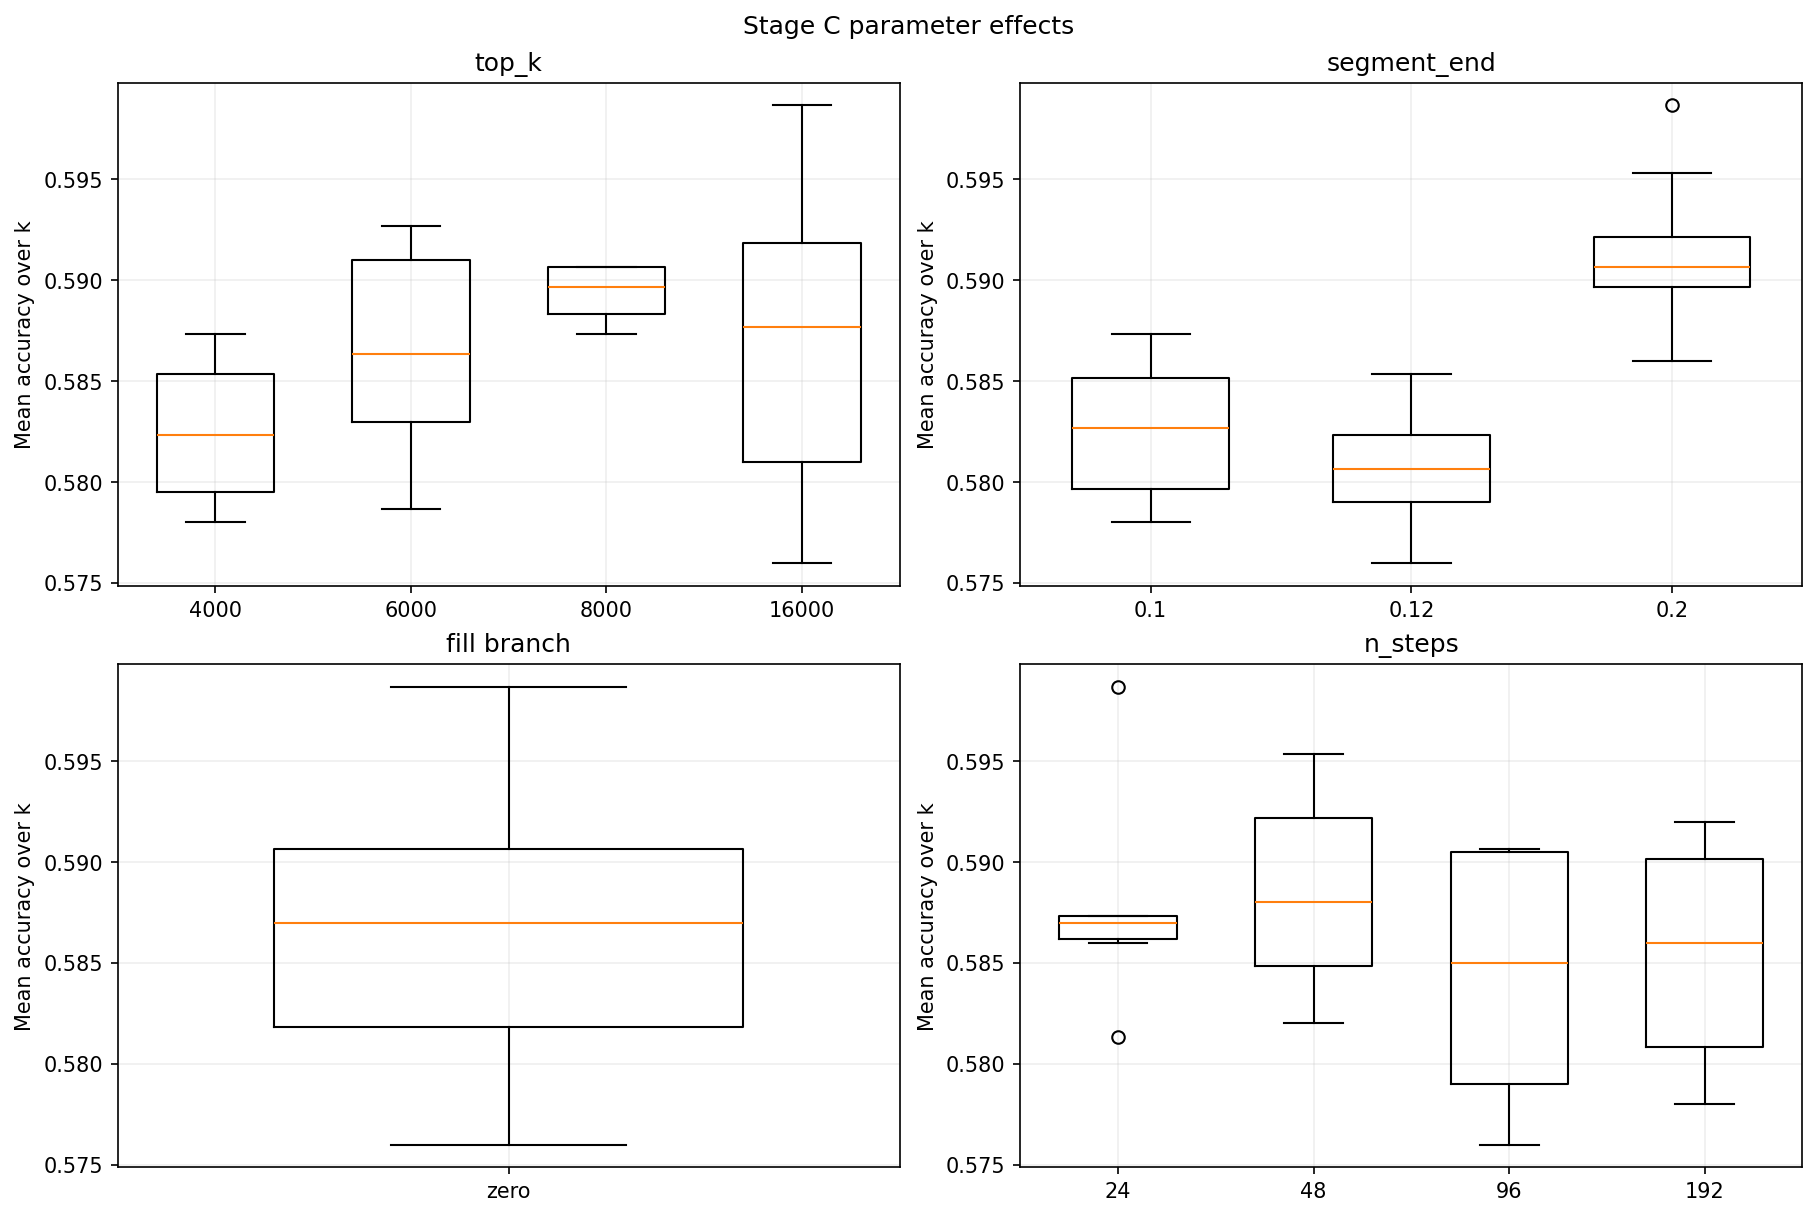

### holdout_curves

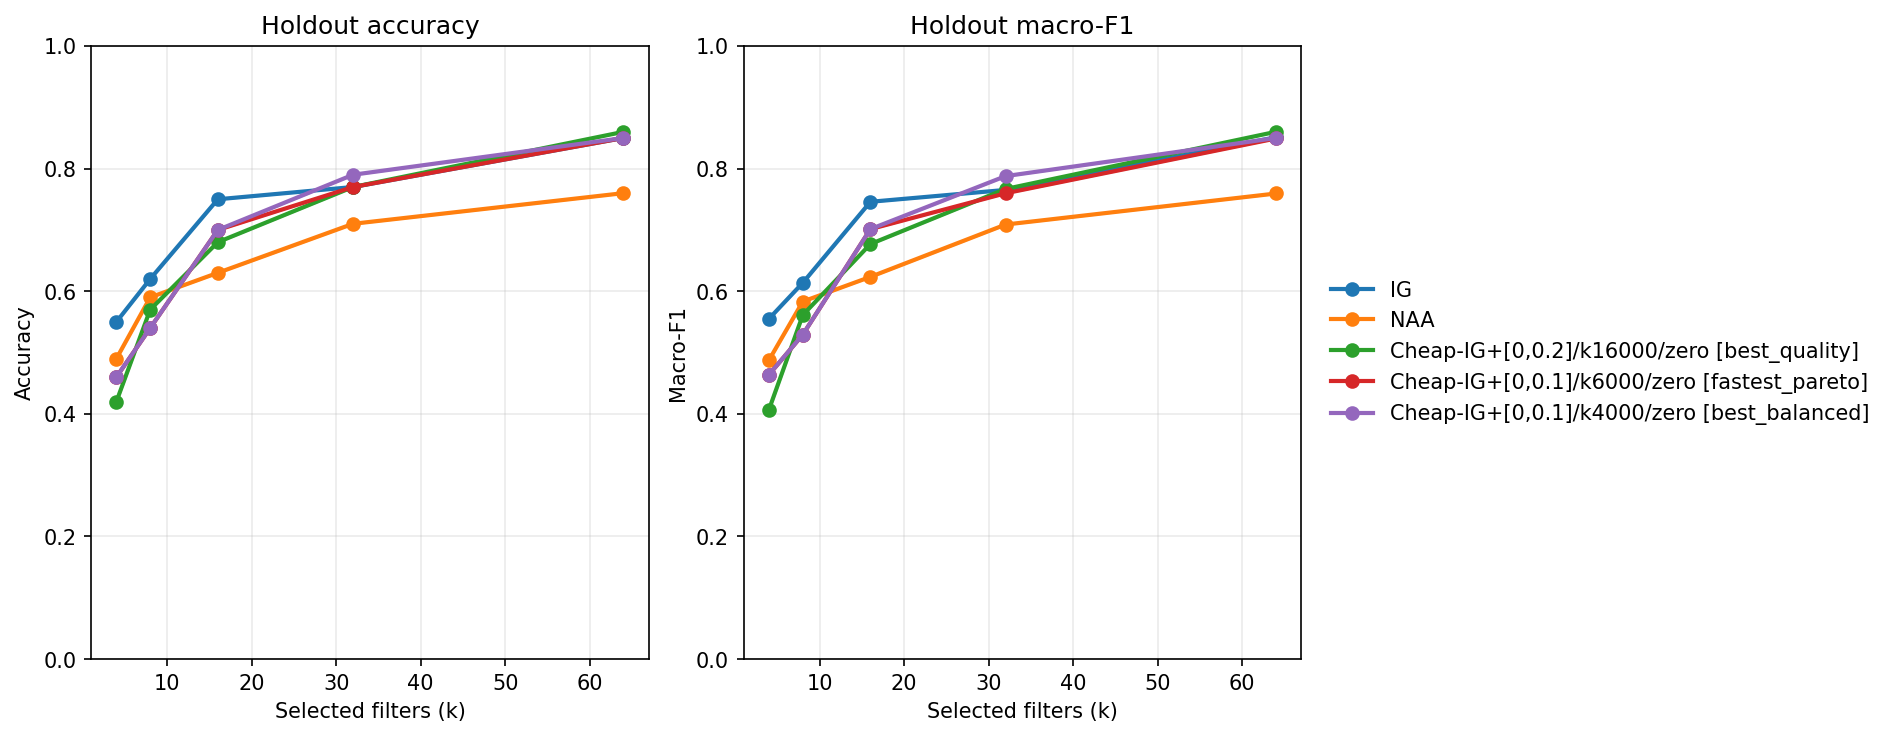

### holdout_summary

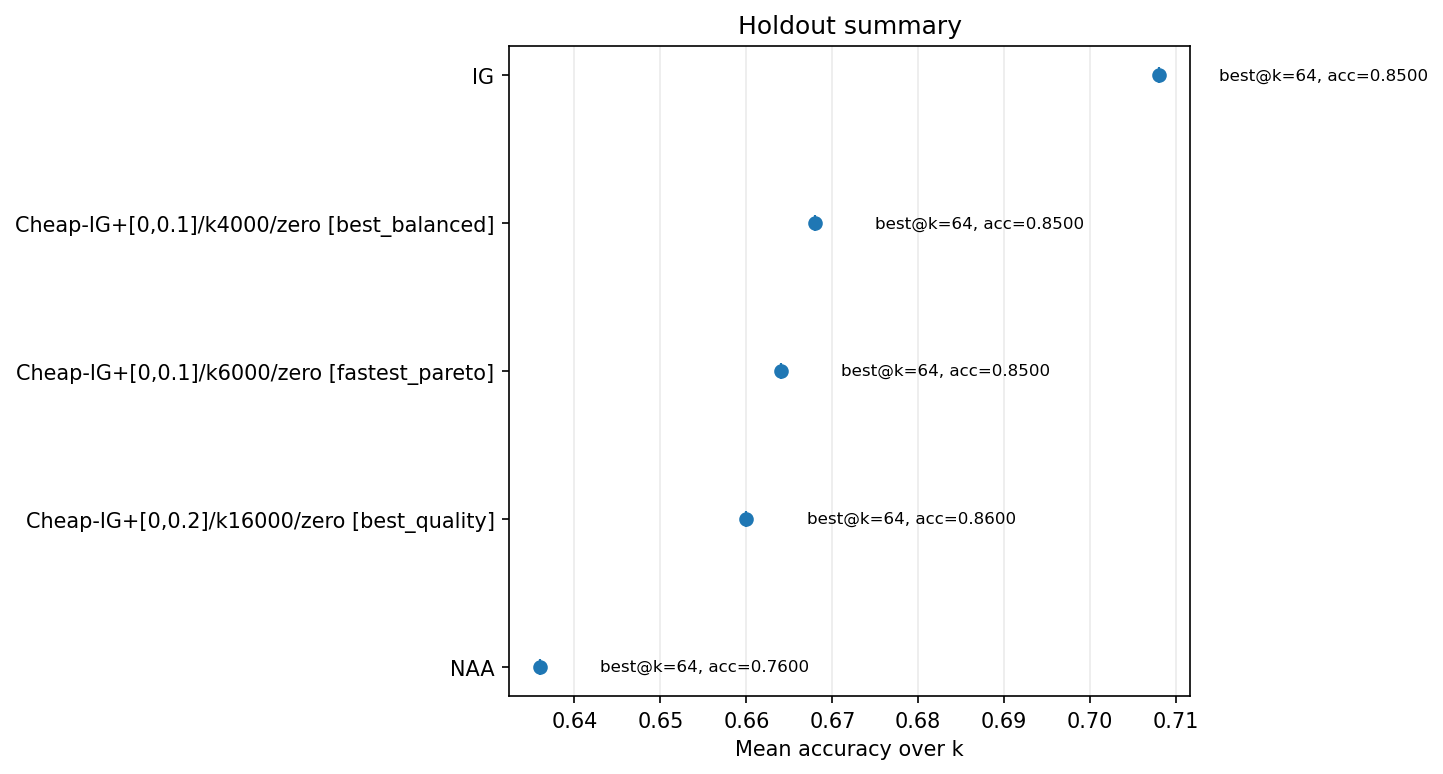

In [14]:
for key, path in ARTIFACTS["figures"].items():
    display(Markdown(f"### {key}"))
    display(Image(filename=path))
